### Задания для практических занятий и самостоятельной работы к главе 2 (4-5)

задание 4

Комбинированный метод хорд и касательных
Интервал: [-4.473684210526316, -3.947368421052632], точность: 1e-06
+------------+----------+-------------+
|   Итерация |        x |        f(x) |
+============+==========+=============+
|          1 | -3.96461 | -0.298827   |
+------------+----------+-------------+
|          2 | -3.96684 | -0.0403585  |
+------------+----------+-------------+
|          3 | -3.96714 | -0.00546937 |
+------------+----------+-------------+
|          4 | -3.96718 | -0.00074155 |
+------------+----------+-------------+
|          5 | -3.96719 | -0.00010055 |
+------------+----------+-------------+
|          6 | -3.96719 | -1.363e-05  |
+------------+----------+-------------+
|          7 | -3.96719 | -1.85e-06   |
+------------+----------+-------------+
|          8 | -3.96719 | -2.5e-07    |
+------------+----------+-------------+

КОРЕНЬ: x = -3.96718620
Итераций: 8
Проверка: f(x) = -0.00000025


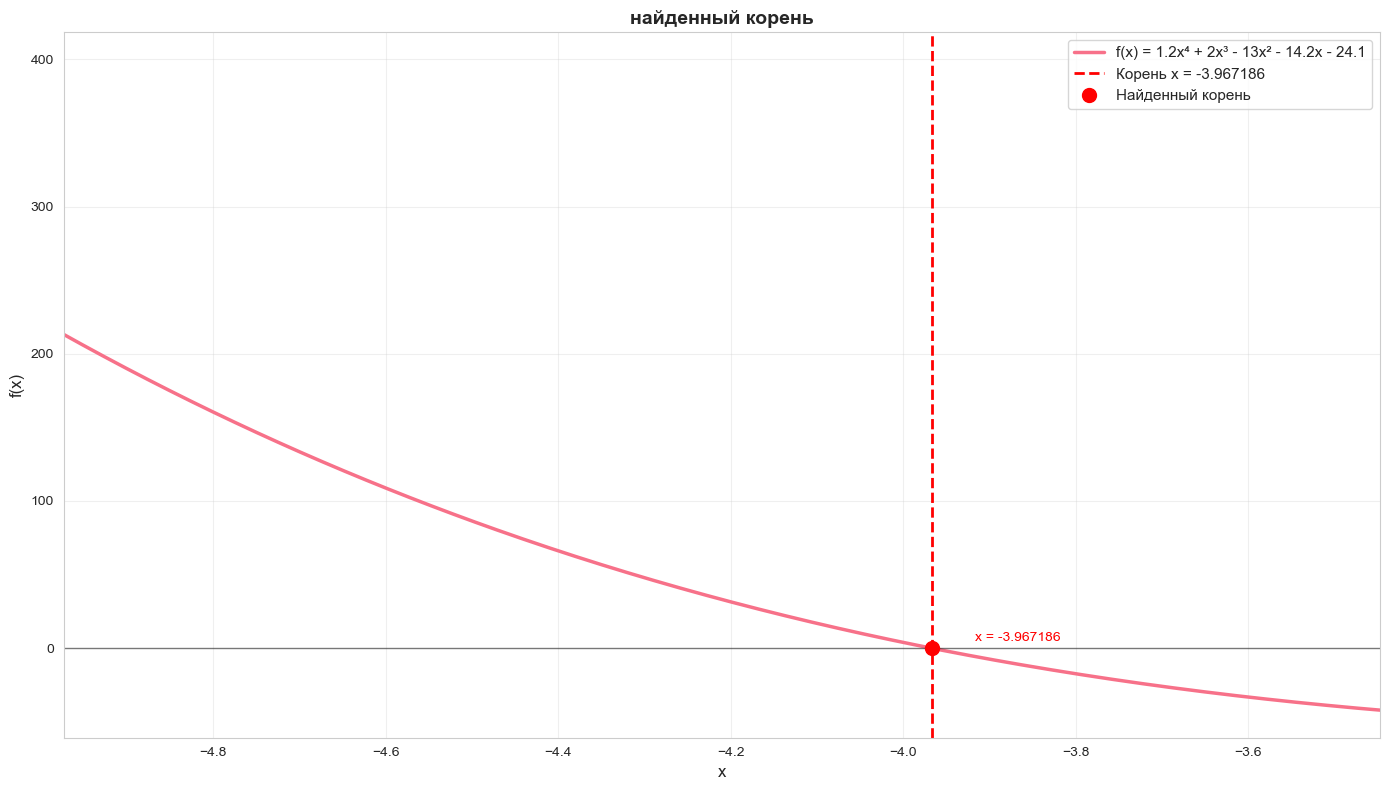

In [ ]:
import math as m
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
import seaborn as sns

# Приводим уравнение к виду f(x) = 0: 1.2x^4 + 2x^3 - 13x^2 - 14.2x - 24.1 = 0
def f(x):
    return 1.2*x**4 + 2*x**3 - 13*x**2 - 14.2*x - 24.1

def f_prime(x):
    return 4.8*x**3 + 6*x**2 - 26*x - 14.2

# Комбинированный метод хорд и касательных
def find_root(a, b, eps=10**-6):
    print("Комбинированный метод хорд и касательных")
    print(f"Интервал: [{a}, {b}], точность: {eps}")
    
    # Создаем список для хранения данных итераций
    iteration_data = []
    
    # Определяем, с какого конца применять метод касательных
    # Выбираем тот конец, где знак функции совпадает со знаком второй производной
    x0 = a if f(a) * (4.8*a**3 + 6*a**2 - 26*a - 14.2) > 0 else b
    
    for i in range(50):
        # Метод хорд
        x_chord = a - f(a)*(b-a)/(f(b)-f(a))
        
        # Метод касательных 
        if f(x0) * f_prime(x0) > 0:
            x_tangent = x0 - f(x0)/f_prime(x0)
        else:
            x_tangent = x0 - f(x0)/f_prime(x0)
        
        # Комбинированный метод - среднее арифметическое
        x = (x_chord + x_tangent)/2
        
        # Добавляем данные текущей итерации в список
        iteration_data.append([i+1, f"{x:.8f}", f"{f(x):.8f}"])
        
        if abs(f(x)) < eps:
            # Выводим таблицу итераций
            headers = ["Итерация", "x", "f(x)"]
            print(tabulate(iteration_data, headers=headers, tablefmt="grid"))
            return x, i+1
        
        # Обновляем интервал
        if f(a) * f(x) < 0:
            b = x
        else:
            a = x
        
        # Обновляем начальную точку для метода касательных
        x0 = x
    
    # Выводим таблицу итераций
    headers = ["Итерация", "x", "f(x)"]
    print(tabulate(iteration_data, headers=headers, tablefmt="grid"))
    return (a+b)/2, 50

# Находим интервал, содержащий корень
x_vals_check = np.linspace(-5, 5, 20)
for i in range(len(x_vals_check)-1):
    if f(x_vals_check[i]) * f(x_vals_check[i+1]) < 0:
        a, b = x_vals_check[i], x_vals_check[i+1]
        break

# Находим корень
root, iter_n = find_root(a, b)

print(f"\nКОРЕНЬ: x = {root:.8f}")
print(f"Итераций: {iter_n}")
print(f"Проверка: f(x) = {f(root):.8f}")


sns.set_style("whitegrid")
sns.set_palette("husl")


plt.figure(figsize=(14, 8))


x_vals = np.linspace(a-1, b+1, 500)
y_vals = [1.2*xi**4 + 2*xi**3 - 13*xi**2 - 14.2*xi - 24.1 for xi in x_vals]


sns.lineplot(x=x_vals, y=y_vals, linewidth=2.5, label='f(x) = 1.2x⁴ + 2x³ - 13x² - 14.2x - 24.1')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.axvline(x=root, color='red', linestyle='--', linewidth=2, label=f'Корень x = {root:.6f}')
plt.plot(root, f(root), 'ro', markersize=10, label='Найденный корень')
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('найденный корень', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xlim(a-0.5, b+0.5)
plt.ylim(min(y_vals)-5, max(y_vals)+5)
plt.text(root+0.05, f(root)+5, f'x = {root:.6f}', fontsize=10, color='red')
plt.tight_layout()
plt.show()


задание 5

   Корень: x = -3.9671862012
   Значение функции: f(x) = -7.11e-15
   Число вычислений функции: 5


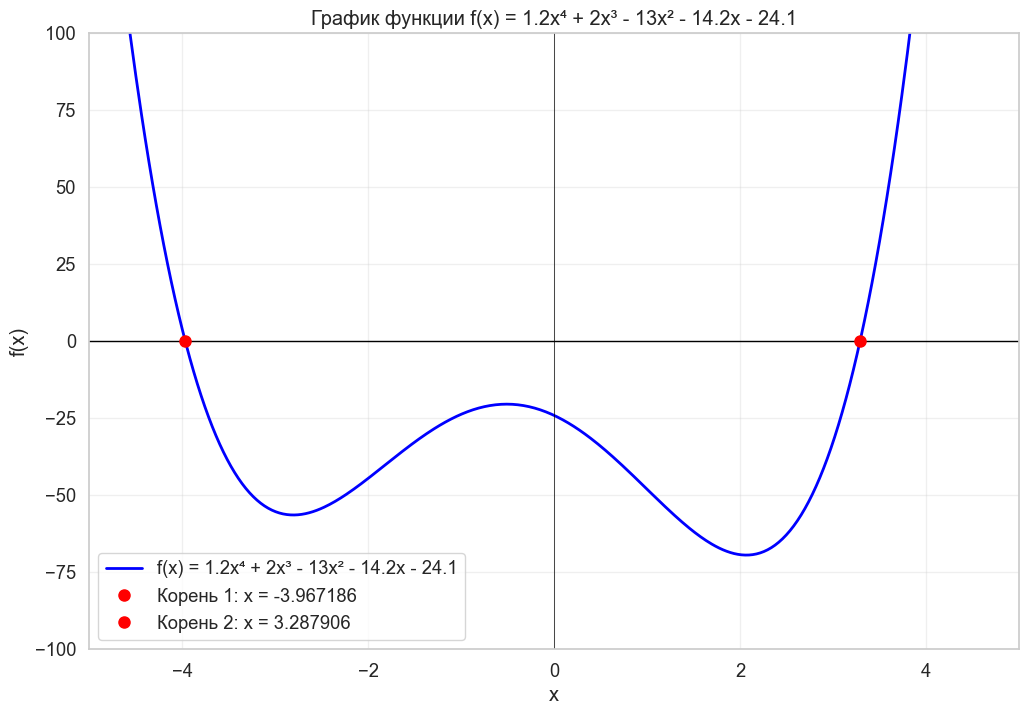

In [ ]:
import numpy as np
from scipy.optimize import root, fsolve
import matplotlib.pyplot as plt
import seaborn as sns

# Приведем уравнение к виду f(x) = 0
# 1.2x^4 + 2x^3 - 24.1 = 13x^2 + 14.2x
# 1.2x^4 + 2x^3 - 13x^2 - 14.2x - 24.1 = 0

def f(x):
    return 1.2*x**4 + 2*x**3 - 13*x**2 - 14.2*x - 24.1

# Найдем все корни многочлена с помощью numpy.roots. Для этого нужны коэффициенты многочлена в порядке убывания степени 
coefficients = [1.2, 2, -13, -14.2, -24.1]
all_roots = np.roots(coefficients)


# Выделим действительные корни
real_roots = [r.real for r in all_roots if abs(r.imag) < 1e-10]


# Используем инструментальный пакет SciPy для уточнения корня
# Выберем начальное приближение около одного из действительных корней
if real_roots:
    x0 = real_roots[0]  # берем первый действительный корень
    
    # fsolve (аналог fzero в MATLAB)
    root_fsolve = fsolve(f, x0, xtol=1e-12, full_output=True)
    x_fsolve = root_fsolve[0][0]
    f_fsolve = f(x_fsolve)
    

    
   
    print(f"   Корень: x = {x_fsolve:.10f}")
    print(f"   Значение функции: f(x) = {f_fsolve:.2e}")
    print(f"   Число вычислений функции: {root_fsolve[1]['nfev']}")
    
    
   
    
    # Визуализация функции и корней
    x_vals = np.linspace(-5, 5, 500)
    y_vals = f(x_vals)
    
    
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.2)
    
    plt.figure(figsize=(12, 8))
    sns.lineplot(x=x_vals, y=y_vals, linewidth=2, label='f(x) = 1.2x⁴ + 2x³ - 13x² - 14.2x - 24.1', color='blue')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=0.5)
    
    # Отметим все действительные корни
    for i, r in enumerate(real_roots):
        plt.plot(r, f(r), 'ro', markersize=8, label=f'Корень {i+1}: x = {r:.6f}')
    
    plt.grid(True, alpha=0.3)
    plt.xlim([-5, 5])
    plt.ylim([-100, 100])
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('График функции f(x) = 1.2x⁴ + 2x³ - 13x² - 14.2x - 24.1')
    plt.legend()
    plt.show()
    
   